In [2]:
import numpy as np
import pandas as pd
import torchaudio
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('../data/train.csv')
df

,text_translated,intent,full_audio_path
0,show my latest transactions,LATEST_TRANSACTIONS,../data/MInDS-14\audio\en-US~LATEST_TRANSACTIO...
1,stop all transactions on my card,FREEZE,../data/MInDS-14\audio\en-AU~FREEZE/response_2...
2,pay a bill,PAY_BILL,../data/MInDS-14\audio\en-AU~PAY_BILL/response...
3,set up a joint account,JOINT_ACCOUNT,../data/MInDS-14\audio\en-US~JOINT_ACCOUNT/602...
4,I want to change my address,ADDRESS,../data/MInDS-14\audio\en-US~ADDRESS/602bae3cb...
...,...,...,...
1442,yeah I know I just wanted to ask you a quick q...,APP_ERROR,../data/MInDS-14\audio\en-US~APP_ERROR/602ba13...
1443,how can I deposit money into my account,CASH_DEPOSIT,../data/MInDS-14\audio\en-AU~CASH_DEPOSIT/resp...
1444,where can I set up a joint account,JOINT_ACCOUNT,../data/MInDS-14\audio\en-AU~JOINT_ACCOUNT/res...
1445,existing line,BUSINESS_LOAN,../data/MInDS-14\audio\en-AU~BUSINESS_LOAN/res...



--- Sample 1 ---
Audio Path: ../data/MInDS-14\audio\en-US~HIGH_VALUE_PAYMENT/602ba93d5f67b421554f644f.wav
Text: hi I need to pay kind of a big amount of money
Sample Rate: 8000 Hz
Number of Frames: 121515
Duration: 15.19 seconds


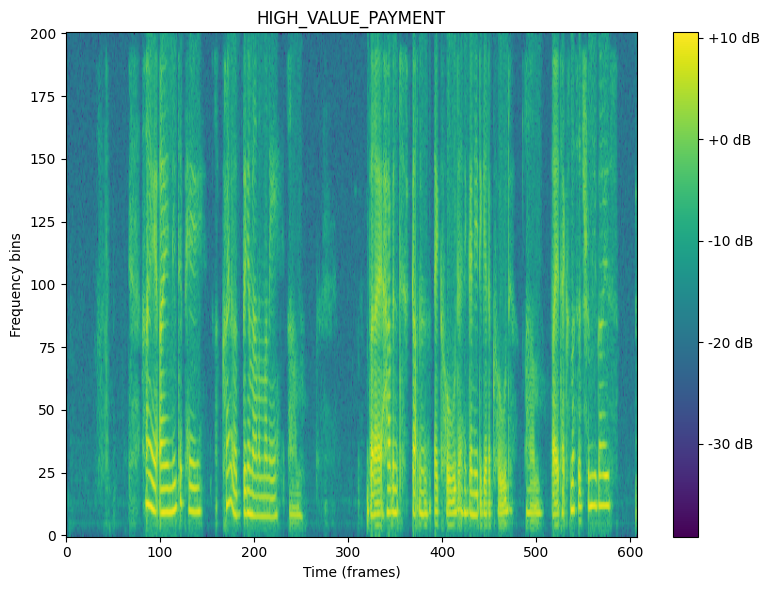


--- Sample 2 ---
Audio Path: ../data/MInDS-14\audio\en-US~JOINT_ACCOUNT/602b9a59bb1e6d0fbce91f51.wav
Text: hello I was just calling to see if I can make it a joint account with my wife thank you
Sample Rate: 8000 Hz
Number of Frames: 52565
Duration: 6.57 seconds


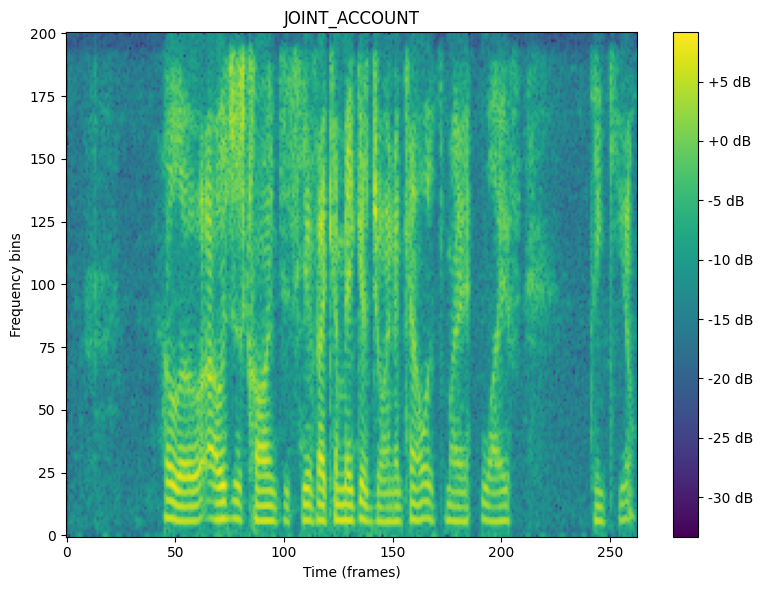


--- Sample 3 ---
Audio Path: ../data/MInDS-14\audio\en-AU~LATEST_TRANSACTIONS/response_16.wav
Text: hello ID like to enquire about my recent transactions could you please check if there's been any payments or transactions that isn't familiar to previous transaction
Sample Rate: 8000 Hz
Number of Frames: 139947
Duration: 17.49 seconds


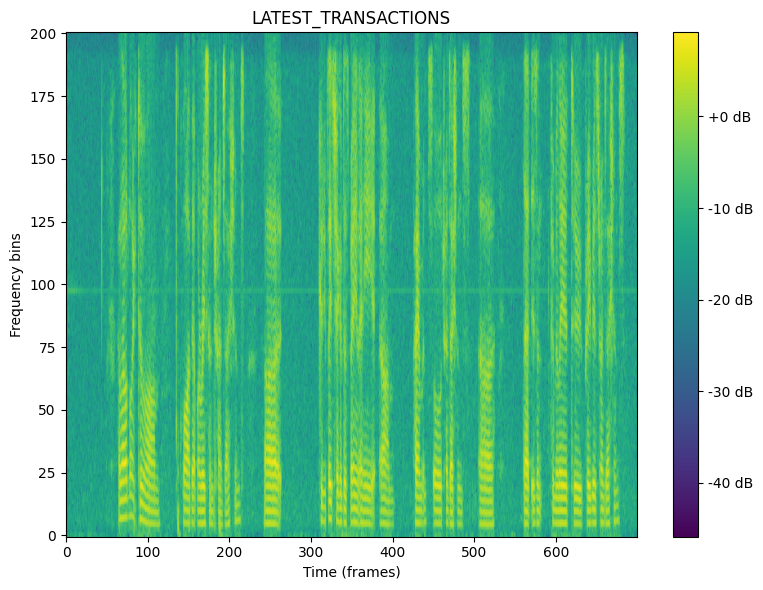


--- Sample 4 ---
Audio Path: ../data/MInDS-14\audio\en-GB~CARD_ISSUES/60268f25c7abb7f832138bc6.wav
Text: my card isn't working it's not letting me take any money out
Sample Rate: 8000 Hz
Number of Frames: 54242
Duration: 6.78 seconds


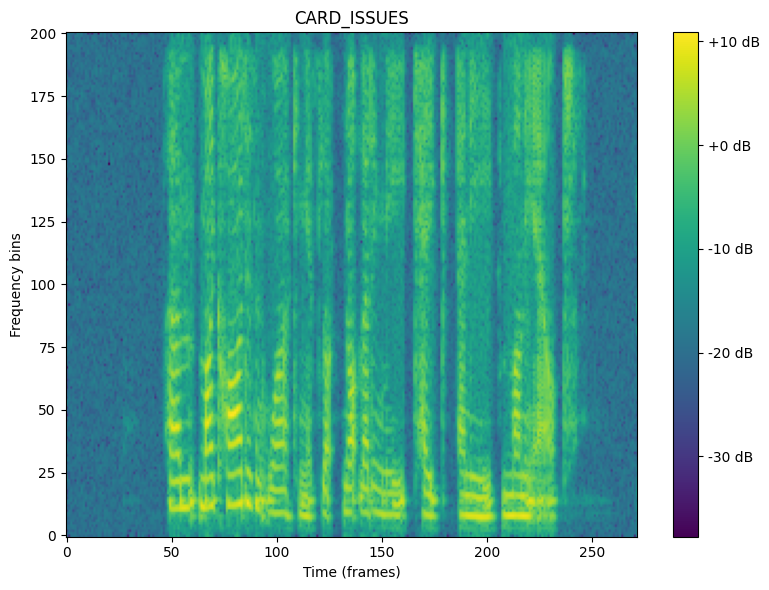


--- Sample 5 ---
Audio Path: ../data/MInDS-14\audio\en-GB~LATEST_TRANSACTIONS/60269013c7abb7f832138def.wav
Text: show me my most recent transactions
Sample Rate: 8000 Hz
Number of Frames: 26624
Duration: 3.33 seconds


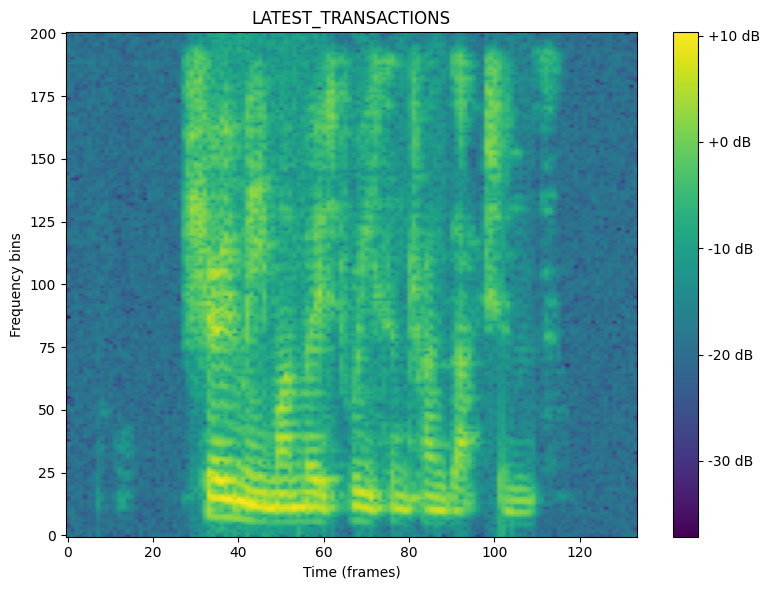


--- Sample 6 ---
Audio Path: ../data/MInDS-14\audio\en-US~LATEST_TRANSACTIONS/602ba44cbb1e6d0fbce92037.wav
Text: cuz I want to see my latest transactions on my account can you please show me them this is yes yes yes I would do recognize that
Sample Rate: 8000 Hz
Number of Frames: 162725
Duration: 20.34 seconds


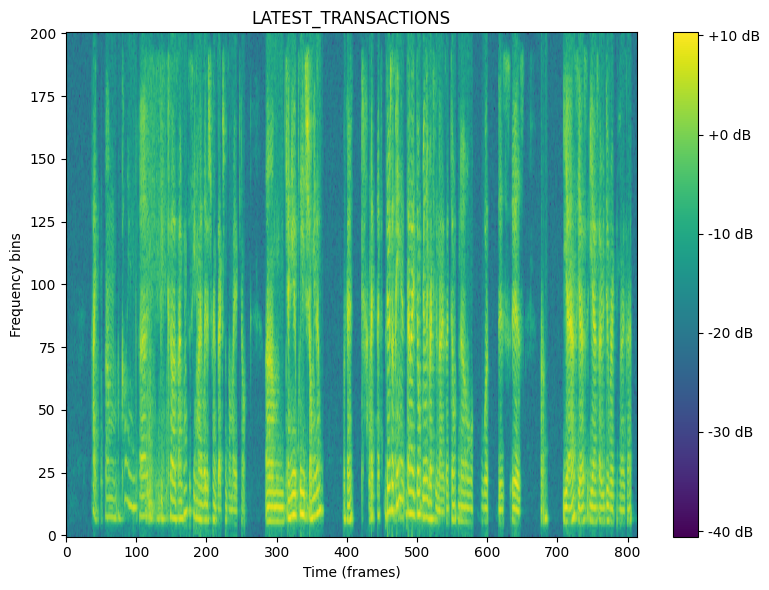

In [5]:
sampled_data = df.sample(n=6).reset_index(drop=True)

for i in range(6):
    sample_row = sampled_data.iloc[i]
    audio_path = sample_row['full_audio_path']

    wave,sample_rate = torchaudio.load(audio_path)  # wave: [channels, num_frames]

    num_frames = wave.shape[1]
    duration_sec = num_frames / sample_rate

    print(f"\n--- Sample {i+1} ---")
    print(f"Audio Path: {audio_path}")
    print(f"Text: {sample_row['text_translated']}")
    print(f"Sample Rate: {sample_rate} Hz")
    print(f"Number of Frames: {num_frames}")
    print(f"Duration: {duration_sec:.2f} seconds")


    spectrogram = torchaudio.transforms.Spectrogram()(wave)

    plt.figure(figsize=(8, 6))
    plt.imshow(spectrogram.log2()[0].numpy(), origin='lower', aspect='auto', cmap='viridis')
    plt.title(f"{sample_row['intent']}")
    plt.xlabel("Time (frames)")
    plt.ylabel("Frequency bins")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

    